In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
import math


plt.style.use("seaborn-v0_8")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
path1 = "../Data/Intermediate/"
input_1 = "SAHMCURRENT_cleaned.csv"

sahm = pd.read_csv(path1 + input_1)
sahm["date"] = pd.to_datetime(sahm["date"])
sahm["sahm"] = sahm["SAHMCURRENT"]
sahm = sahm.sort_values("date")
sahm = sahm.set_index('date')  # set as index

sahm = sahm[["sahm"]]
#sahm.head(5)

In [3]:
input_2 = "all_keywords_long.csv"
df_og = pd.read_csv(path1 + input_2)
df_og['date'] = pd.to_datetime(df_og['date'])

df_og.head(5)

#df_og.info()
#df_og['keyword'].unique()

,date,keyword,category,search_interest
0,2004-01-01,0_percent_APR,Credit_and_debt,0
1,2004-02-01,0_percent_APR,Credit_and_debt,0
2,2004-03-01,0_percent_APR,Credit_and_debt,0
3,2004-04-01,0_percent_APR,Credit_and_debt,0
4,2004-05-01,0_percent_APR,Credit_and_debt,0


In [4]:
trends = df_og.pivot_table(
    index = 'date',
    columns = 'keyword',
    values = 'search_interest'
)

trends = trends.sort_index() #reshape csv into wide format instead of long
#trends.head()

In [5]:
trends_smoothed = trends.rolling(3).mean()
data = trends_smoothed.join(sahm, how = "inner")

data.head()

,0_percent_APR,401k,ACA_marketplace,APR,Airbnb,AngelList,COBRA_insurance,CPI,CV_template,CareerBuilder,...,where_is_my_refund,whole_life_insurance,wine_collection,work_at_home,work_flexibility,work_from_home,workers_compensation_insurance,yacht,yard_sale,sahm
date,,,,,,,,,,,,,,,,,,,,,
2004-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.100
2004-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.070
2004-03-01,0.000,35.000,0.000,32.000,0.000,0.000,55.667,53.000,4.333,14.667,...,1.000,38.000,32.000,84.667,0.000,21.333,83.333,66.000,14.000,0.030
2004-04-01,0.000,31.000,0.000,35.333,0.000,0.000,53.333,53.000,4.667,15.000,...,1.333,36.333,16.667,80.000,0.000,19.667,78.000,68.000,19.333,0.000
2004-05-01,0.000,29.333,0.000,35.667,0.000,0.000,55.333,53.000,6.667,15.000,...,1.333,36.333,29.000,81.667,11.333,20.000,83.667,70.000,26.667,0.000


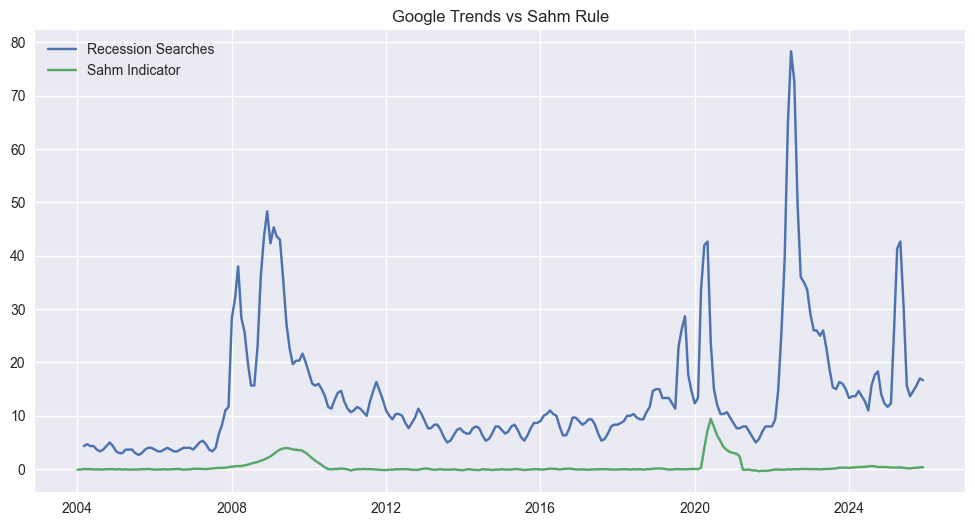

In [6]:
#test run for one set of data

plt.figure(figsize=(12,6))

plt.plot(data.index, data['recession'], label = 'Recession Searches')
plt.plot(data.index, data['sahm'], label = 'Sahm Indicator')

plt.legend()
plt.title("Google Trends vs Sahm Rule")
plt.show()

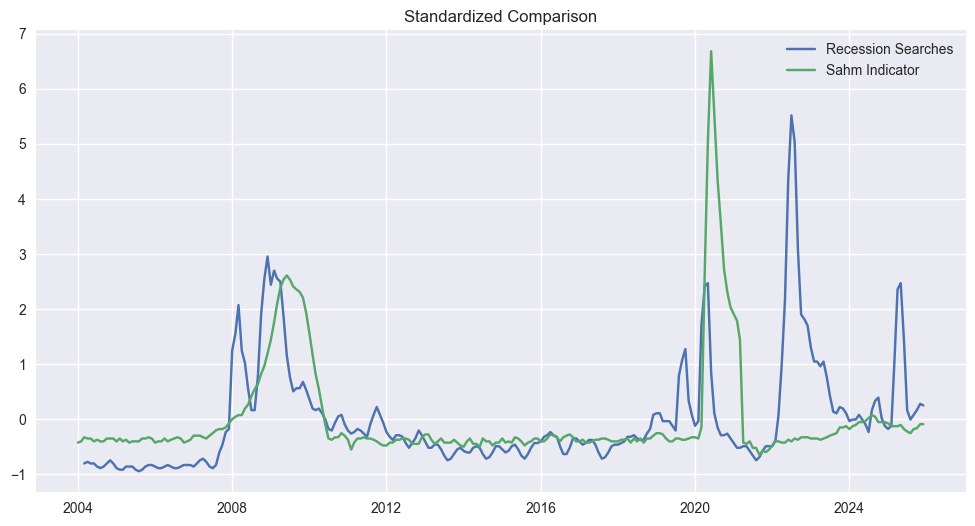

In [7]:
#test run for std 

data_std = (data - data.mean()) / data.std()

plt.figure(figsize=(12,6))
plt.plot(data_std.index, data_std['recession'], label = 'Recession Searches')
plt.plot(data_std.index, data_std['sahm'], label = 'Sahm Indicator')
plt.title("Standardized Comparison")
plt.legend()
plt.show()

In [8]:
corrs = data.corr()["sahm"].drop("sahm") #computes correlation matrix

all_corrs = corrs.abs().sort_values(ascending = False).index
# all_corrs_df = pd.DataFrame({
#     "keyword": all_corrs,
#     "corr_with_sahm": corrs[all_corrs].values
# })

top_keywords = corrs.abs().sort_values(ascending = False).head(12).index

#finds the top 12 keywords that correlate most of sahm
#ignores postive and negative, we care about magnitude 

top_corrs = pd.DataFrame({
    "keyword": top_keywords,
    "corr_with_sahm": corrs[top_keywords].values
})

top_corrs

,keyword,corr_with_sahm
0,unemployment_benefits,0.843
1,online_teaching,0.725
2,pandemic_relief_fund,0.711
3,file_for_unemployment,0.711
4,refinance_mortgage,0.709
5,mortgage_refinance,0.709
6,SBA_loan,0.661
7,small_business_grant,0.627
8,stimulus_check,0.613
9,stimulus_payment_status,0.589


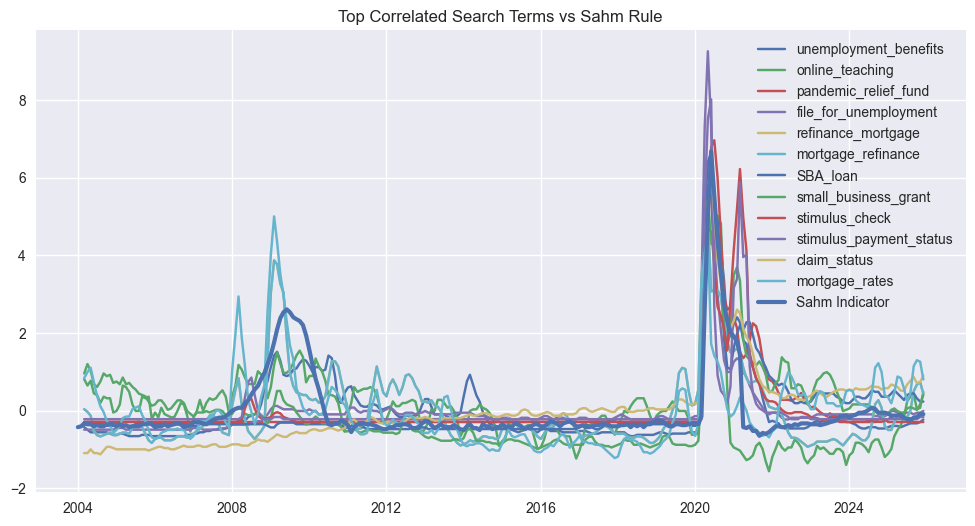

In [9]:
plt.figure(figsize=(12,6))

for k in top_keywords:
    plt.plot(data_std.index, data_std[k], label = k)

plt.plot(data_std.index, data_std["sahm"], linewidth = 3, label = "Sahm Indicator")

plt.legend()
plt.title("Top Correlated Search Terms vs Sahm Rule")
plt.show()

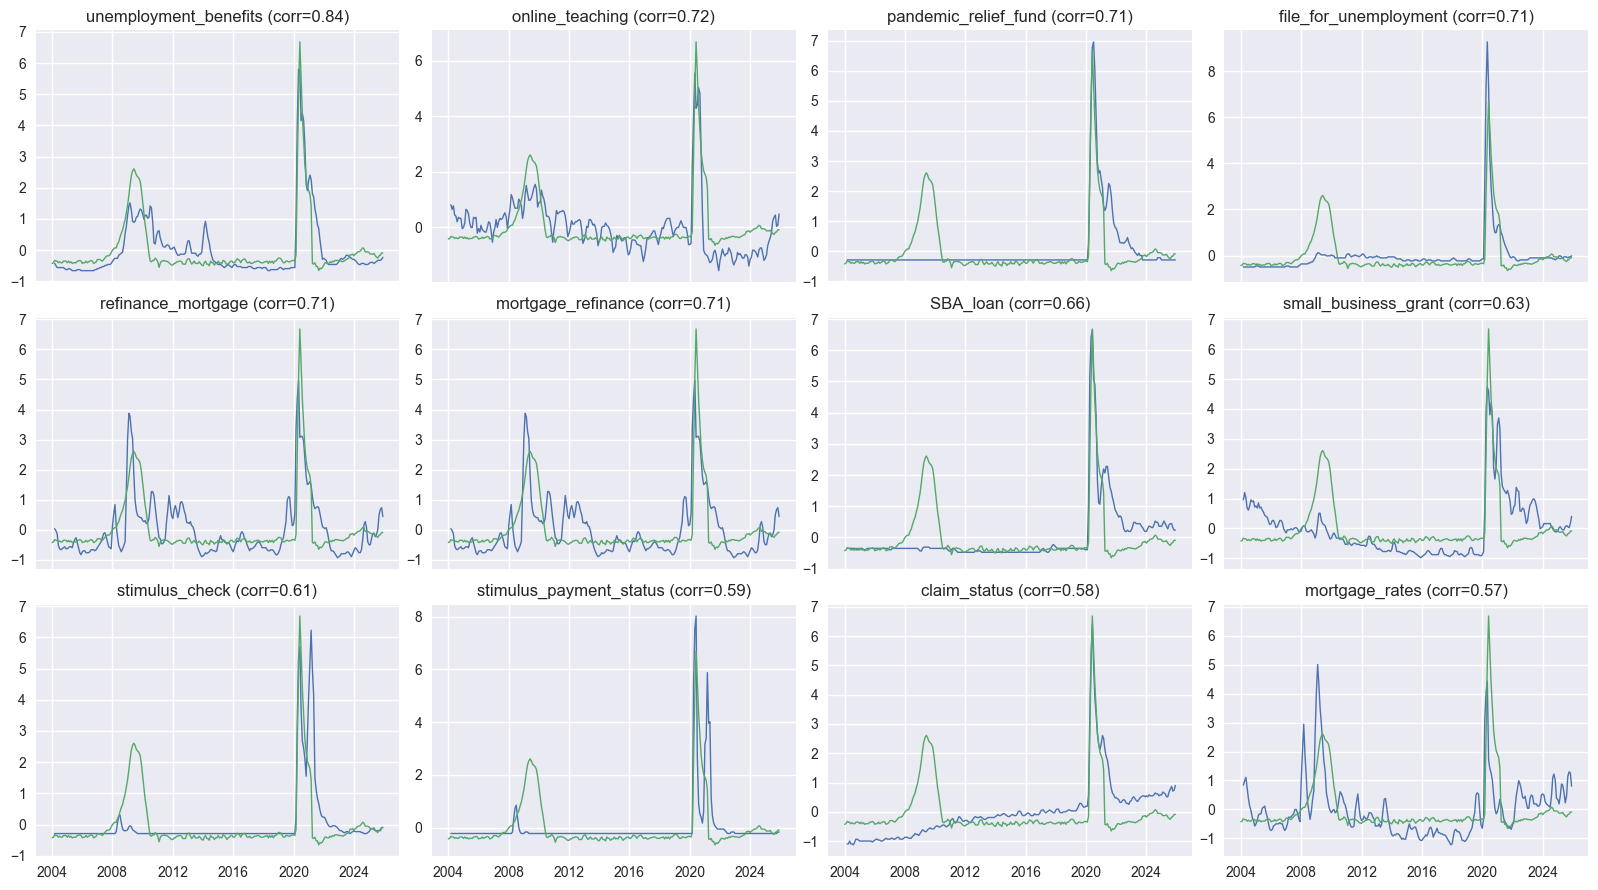

In [10]:
keywords = list(top_keywords)
n = len(keywords)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 3*rows), sharex=True)
axes = axes.flatten()

for i, k in enumerate(keywords):
    axes[i].plot(data_std.index, data_std[k], linewidth = 1)
    axes[i].plot(data_std.index, data_std["sahm"], linewidth = 1)
    axes[i].set_title(f"{k} (corr={corrs[k]:.2f})")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

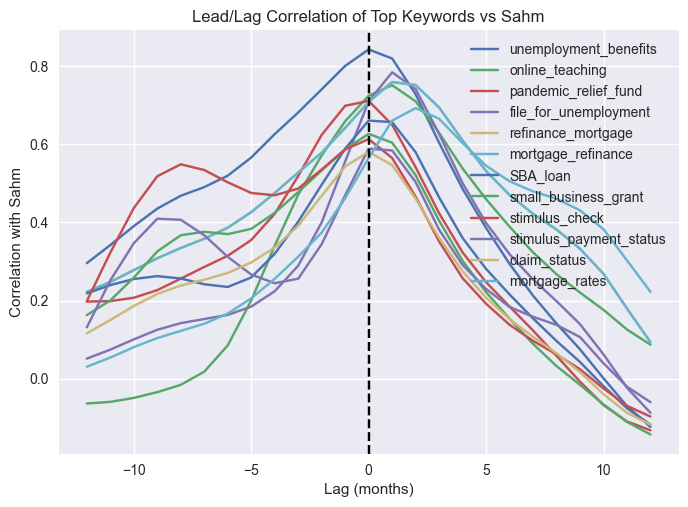

In [11]:
lags = range(-12, 13)

for k in top_keywords[:12]:   # top 12 keywords
    lag_corrs = [data[k].shift(l).corr(data["sahm"]) for l in lags]
    plt.plot(lags, lag_corrs, label=k)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation with Sahm")
plt.title("Lead/Lag Correlation of Top Keywords vs Sahm")
plt.legend()
plt.show()

#Positive lag: keyword leads Sahm by x month
#Negative lag: Sahm leads the keyword

In [12]:
results = []

for k in top_keywords[:12]:
    lag_corrs = [data[k].shift(l).corr(data["sahm"]) for l in lags]
    max_corr = max(lag_corrs)
    lead_lag = lags[lag_corrs.index(max_corr)]
    results.append((k, max_corr, lead_lag))

lead_table = pd.DataFrame(results, columns = ["keyword","max_corr","lead_lag_months"])
lead_table_sorted = lead_table.sort_values(by = "lead_lag_months", ascending = False)
lead_table_sorted

,keyword,max_corr,lead_lag_months
11,mortgage_rates,0.693,2
1,online_teaching,0.752,1
4,refinance_mortgage,0.760,1
3,file_for_unemployment,0.785,1
5,mortgage_refinance,0.760,1
0,unemployment_benefits,0.843,0
2,pandemic_relief_fund,0.711,0
6,SBA_loan,0.661,0
7,small_business_grant,0.627,0
8,stimulus_check,0.613,0


In [13]:
from scipy.stats import pearsonr

df = data.copy() 
r_results = []

for index, row in lead_table_sorted.iterrows():
    kw = row['keyword']
    lag = int(row['lead_lag_months'])

    # apply lag
    x = df[kw].shift(lag)
    y = df['sahm']

    # align and drop NaNs
    combined = pd.concat([x, y], axis=1).dropna()
    if combined.empty:
        continue

    # Compute correlation and p-value
    corr, pval = pearsonr(combined[kw], combined['sahm'])
    r_results.append((kw, corr, pval, lag))

df_stats = pd.DataFrame(
    r_results, 
    columns = ["keyword","max_corr","p_value","lead_lag_months"])
df_stats = df_stats.sort_values(
    "lead_lag_months", 
    ascending = False).reset_index(drop = True)

df_stats

,keyword,max_corr,p_value,lead_lag_months
0,mortgage_rates,0.693,0.000,2
1,online_teaching,0.752,0.000,1
2,refinance_mortgage,0.760,0.000,1
3,file_for_unemployment,0.785,0.000,1
4,mortgage_refinance,0.760,0.000,1
5,unemployment_benefits,0.843,0.000,0
6,pandemic_relief_fund,0.711,0.000,0
7,SBA_loan,0.661,0.000,0
8,small_business_grant,0.627,0.000,0
9,stimulus_check,0.613,0.000,0


In [14]:
lags = np.arange(-12, 13) 
res = []

for k in all_corrs:
    lag_corrs = [data[k].shift(l).corr(data["sahm"]) for l in lags]
    max_corr = max(lag_corrs)
    lead_lag = lags[lag_corrs.index(max_corr)]
    res.append((k, max_corr, lead_lag))

all_lead_table = pd.DataFrame(res, columns = ["keyword","max_corr","lead_lag_months"])
all_lead_table_sorted = all_lead_table.sort_values(by = "max_corr", ascending = False)
all_lead_table_sorted

,keyword,max_corr,lead_lag_months
0,unemployment_benefits,0.843,0
3,file_for_unemployment,0.785,1
5,mortgage_refinance,0.760,1
4,refinance_mortgage,0.760,1
1,online_teaching,0.752,1
...,...,...,...
77,coupon_apps,-0.112,-12
69,TaskRabbit,-0.128,11
49,credit_card_application,-0.131,-12
45,Monster,-0.150,-12


In [15]:
r_res = []

for index, row in all_lead_table_sorted.iterrows():
    kw = row['keyword']
    lag = int(row['lead_lag_months'])

    # apply lag
    x = df[kw].shift(lag)
    y = df['sahm']

    # align and drop NaNs
    combined = pd.concat([x, y], axis = 1).dropna()
    if combined.empty:
        continue

    # Compute correlation and p-value
    corr, pval = pearsonr(combined[kw], combined['sahm'])
    r_res.append((kw, corr, pval, lag))

all_df_stats = pd.DataFrame(
    r_res, 
    columns = ["keyword","max_corr","p_value","lead_lag_months"])
all_df_stats = all_df_stats.sort_values(
    "p_value", 
    ascending = True).reset_index(drop = True)

all_df_stats

,keyword,max_corr,p_value,lead_lag_months
0,unemployment_benefits,0.843,0.000,0
1,file_for_unemployment,0.785,0.000,1
2,mortgage_refinance,0.760,0.000,1
3,refinance_mortgage,0.760,0.000,1
4,online_teaching,0.752,0.000,1
...,...,...,...,...
481,rare_wine,0.001,0.987,5
482,insurance_claim,0.001,0.990,-12
483,luxury_travel,0.001,0.992,12
484,fine_jewelry,0.000,0.999,5


In [16]:
# Keep rows where p_value < 0.05 AND max_corr >= 0.4 AND lead_lag_months >= 0
filtered_all_df_stats = all_df_stats[
    (all_df_stats['p_value'] < 0.05) & 
    (all_df_stats['max_corr'] >= 0.4) & 
    (all_df_stats['lead_lag_months'] >= 0)
].copy()

filtered_all_df_stats['p_value_formatted'] = filtered_all_df_stats['p_value'].apply(lambda x: f"{x:.3e}")
filtered_all_df_stats = filtered_all_df_stats.sort_values(
    "p_value", 
    ascending=True
).reset_index(drop=True)
cols = ['keyword', 'max_corr', 'p_value', 'p_value_formatted', 'lead_lag_months']
filtered_all_df_stats = filtered_all_df_stats[cols]
filtered_all_df_stats

,keyword,max_corr,p_value,p_value_formatted,lead_lag_months
0,unemployment_benefits,0.843,0.000,5.593e-72,0
1,file_for_unemployment,0.785,0.000,1.124e-55,1
2,mortgage_refinance,0.760,0.000,2.597e-50,1
3,refinance_mortgage,0.760,0.000,2.597e-50,1
4,online_teaching,0.752,0.000,1.078e-48,1
5,pandemic_relief_fund,0.711,0.000,1.081e-41,0
6,mortgage_rates,0.693,0.000,1.636e-38,2
7,SBA_loan,0.661,0.000,2.813e-34,0
8,small_business_grant,0.627,0.000,4.926e-30,0
9,stimulus_check,0.613,0.000,1.786e-28,0


In [17]:
# for p in filtered_all_df_stats['p_value']:
#     print(f"{p:.3e}")

#print("\n" + filtered_all_df_stats['max_corr'].to_string())

In [18]:
kw_cat = df_og[['keyword', 'category']].drop_duplicates()

# attach categories to your selected keywords
merged = filtered_all_df_stats.merge(kw_cat, on = 'keyword', how = 'left')

# count categories
category_counts = (
    merged.groupby('category')['keyword']
    .nunique()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print(merged[['keyword','category']])
category_counts

                    keyword                 category
0     unemployment_benefits       Government_support
1     file_for_unemployment       Government_support
2        mortgage_refinance          Credit_and_debt
3        refinance_mortgage  Housing_rent_and_stress
4           online_teaching                     Jobs
5      pandemic_relief_fund       Government_support
6            mortgage_rates  Housing_rent_and_stress
7            mortgage_rates                Inflation
8                  SBA_loan       Government_support
9      small_business_grant       Government_support
10           stimulus_check       Government_support
11  stimulus_payment_status       Government_support
12             claim_status                Insurance
13         blue_chip_stocks    Investing_and_markets
14             stock_market    Investing_and_markets
15      mortgage_assistance  Housing_rent_and_stress
16                Dow_Jones    Investing_and_markets
17        credit_monitoring          Credit_an

,category,count
1,Government_support,7
5,Investing_and_markets,5
2,Housing_rent_and_stress,3
0,Credit_and_debt,2
3,Inflation,1
4,Insurance,1
6,Jobs,1
